# Pneumonia Detection Baseline (EfficientNet-B0)

Notebook này gồm:
- Load dataset
- Kiểm tra class imbalance
- Fix imbalance bằng Weighted Loss + WeightedRandomSampler
- Train baseline EfficientNet-B0
- Validate / test


In [1]:
import os
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torchvision.models as models

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from tqdm import tqdm


In [2]:
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
# Sửa đường dẫn nếu cần
data_root = Path(r'D:/Resfes/dataset_binary')

train_dir = data_root / 'train'
val_dir   = data_root / 'val'
test_dir  = data_root / 'test'

print('Train:', train_dir)
print('Val:', val_dir)
print('Test:', test_dir)

assert train_dir.exists(), f'Không tìm thấy: {train_dir}'
assert val_dir.exists(), f'Không tìm thấy: {val_dir}'
assert test_dir.exists(), f'Không tìm thấy: {test_dir}'


Train: D:\Resfes\dataset_binary\train
Val: D:\Resfes\dataset_binary\val
Test: D:\Resfes\dataset_binary\test


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transform)

print('Train samples:', len(train_dataset))
print('Val samples:', len(val_dataset))
print('Test samples:', len(test_dataset))
print('Class mapping:', train_dataset.class_to_idx)


Train samples: 3650
Val samples: 782
Test samples: 784
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [6]:
# Kiểm tra class imbalance
train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)

print('Class counts:', class_counts)

num_samples = sum(class_counts.values())
class_weights = torch.tensor(
    [
        num_samples / class_counts[0],  # NORMAL
        num_samples / class_counts[1],  # PNEUMONIA
    ],
    dtype=torch.float,
).to(device)

print('Class weights:', class_weights)


Class counts: Counter({1: 2712, 0: 938})
Class weights: tensor([3.8913, 1.3459], device='cuda:0')


In [7]:
# WeightedRandomSampler để batch cân bằng hơn
class_sample_weights = {
    0: 1.0 / class_counts[0],
    1: 1.0 / class_counts[1],
}

sample_weights = [class_sample_weights[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)


In [23]:
# Trên Windows, nếu num_workers=4 bị lỗi thì đổi về 0 hoặc 2
NUM_WORKERS = 0
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)


In [24]:
images, labels = next(iter(train_loader))
print('Image batch shape:', images.shape)
print('Label batch shape:', labels.shape)
print('First 20 labels:', labels[:20])


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 20 labels: tensor([1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0])


In [25]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

print(model.classifier)


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [26]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()


C:\Users\PC\AppData\Local\Temp\ipykernel_25296\2079884880.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [27]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader, desc='Training', leave=False)

    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [28]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader, desc='Validation', leave=False)

    with torch.no_grad():
        for images, labels in loop:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [29]:
num_epochs = 3
best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f'\nEpoch [{epoch+1}/{num_epochs}]')

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, scaler
    )
    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_efficientnet_b0.pth')
        print('Saved best model!')



Epoch [1/3]


Training:   0%|          | 0/115 [00:00<?, ?it/s]C:\Users\PC\AppData\Local\Temp\ipykernel_25296\780580417.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation:   0%|          | 0/25 [00:00<?, ?it/s]                      C:\Users\PC\AppData\Local\Temp\ipykernel_25296\3035188152.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 0.1746 | Train Acc: 0.9222
Val   Loss: 0.0929 | Val   Acc: 0.9680
Saved best model!

Epoch [2/3]


Train Loss: 0.0586 | Train Acc: 0.9767
Val   Loss: 0.0632 | Val   Acc: 0.9783
Saved best model!

Epoch [3/3]


Train Loss: 0.0418 | Train Acc: 0.9822
Val   Loss: 0.0709 | Val   Acc: 0.9744


In [30]:
model.load_state_dict(torch.load('best_efficientnet_b0.pth'))
model.eval()
print('Best model loaded successfully!')


Best model loaded successfully!


C:\Users\PC\AppData\Local\Temp\ipykernel_25296\3592455877.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_efficientnet_b0.pth'))


In [31]:
test_loss, test_acc = validate_one_epoch(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Acc : {test_acc:.4f}')


Validation:   0%|          | 0/25 [00:00<?, ?it/s]C:\Users\PC\AppData\Local\Temp\ipykernel_25296\3035188152.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
                                                                         

Test Loss: 0.0763
Test Acc : 0.9770


In [32]:
images, labels = next(iter(test_loader))
images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

print('True labels :', labels[:10].cpu().numpy())
print('Pred labels :', preds[:10].cpu().numpy())


True labels : [0 0 0 0 0 0 0 0 0 0]
Pred labels : [0 0 0 0 0 0 0 0 0 0]


In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001A3FD401760>
Traceback (most recent call last):
  File "c:\Users\PC\yolovenv\Lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "c:\Users\PC\yolovenv\Lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


In [34]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Done!")
print("Total test samples:", len(all_labels))

Done!
Total test samples: 784


In [35]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[198   4]
 [ 13 569]]


In [36]:
class_names = list(test_dataset.class_to_idx.keys())

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      NORMAL       0.94      0.98      0.96       202
   PNEUMONIA       0.99      0.98      0.99       582

    accuracy                           0.98       784
   macro avg       0.97      0.98      0.97       784
weighted avg       0.98      0.98      0.98       784



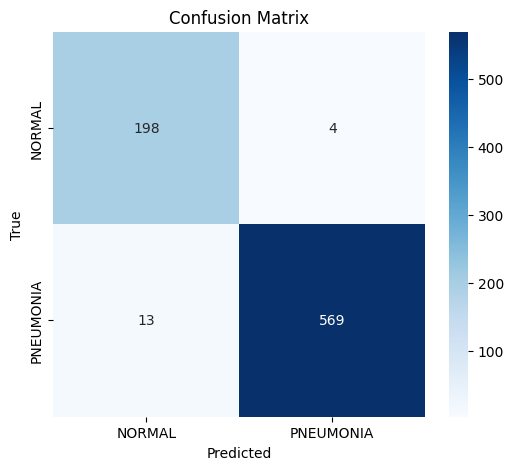

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

The model achieved high classification performance with an overall accuracy of 97.8%. The confusion matrix shows that most samples were correctly classified, with only 17 misclassifications out of 784 test images.

The model demonstrates strong sensitivity to pneumonia cases (recall = 0.98), ensuring that most diseased cases are correctly detected. Although a small number of normal cases were misclassified as pneumonia, this behavior is acceptable in clinical settings where false negatives are more critical than false positives.

Overall, the model provides a good balance between sensitivity and specificity, making it suitable for preliminary clinical decision support.

In [3]:
train_losses = [0.1746, 0.0586, 0.0418]
val_losses   = [0.0929, 0.0632, 0.0709]

train_accs = [0.9222, 0.9767, 0.9822]
val_accs   = [0.9680, 0.9783, 0.9744]

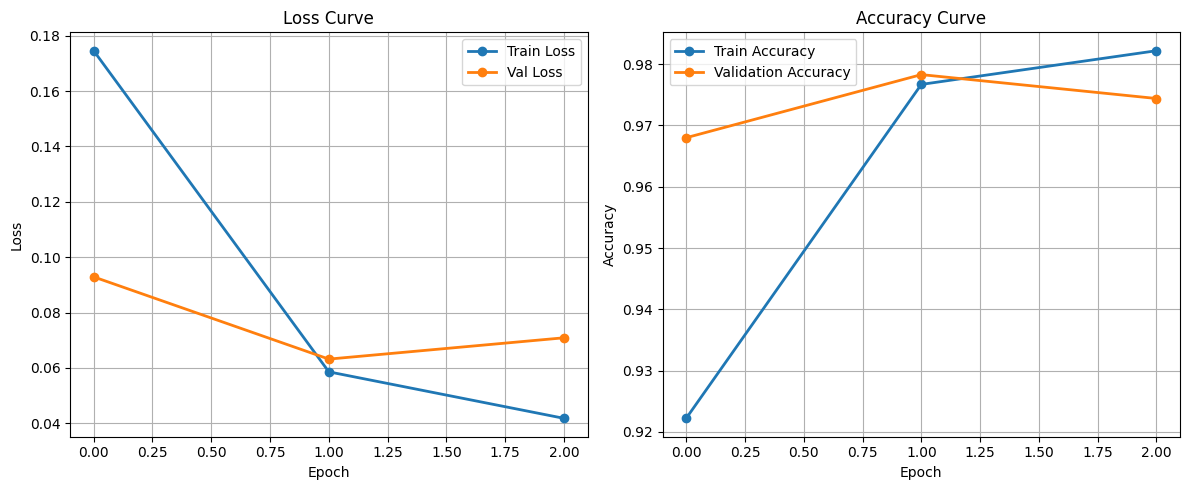

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Loss
ax[0].plot(train_losses, marker='o', linewidth=2, label="Train Loss")
ax[0].plot(val_losses, marker='o', linewidth=2, label="Val Loss")
ax[0].set_title("Loss Curve")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(train_accs, marker='o', linewidth=2, label="Train Accuracy")
ax[1].plot(val_accs, marker='o', linewidth=2, label="Validation Accuracy")
ax[1].set_title("Accuracy Curve")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()